# EDA ADVANCED v3 — trouver le signal que la corrélation univariée ne voit pas

**v2 n'a pas donné de résultat exploitable — ce notebook n'en dépend plus.** v3 lit
directement `dataset_eligibilite_final` (même chemin qu'`EDA_ultimate_eligibilite` et que
`pipeline_fast_tuning` — 3.17M lignes, déjà nettoyé par `traiter_dataset()` : dédup, nulls,
outliers, imputation), plutôt que la sortie dérivée de v2. C'est un remplacement de
`EDA_ultimate` (partie 2bis, sections 11-17) et de v2, pas une suite qui en hérite la config.

**Pourquoi une approche différente de la corrélation univariée**

Ce que `EDA_ultimate` avait préparé (jamais exécuté) et ce que v2 a exécuté calculaient tous
les deux la même famille de mesures : Pearson `r`, Cramér's V, lift. Ce sont des mesures
**linéaires / marginales**. Sur un problème à ~4.6% de positifs, trois choses cassent ce
type de mesure sans que la feature soit inutile pour autant :

1. **Relation non-monotone** (ex. un flux moyen prédictif seulement dans les extrêmes,
   pas au milieu) — Pearson `r` peut être proche de 0 alors que la feature sépare bien
   les classes une fois binée.
2. **Interaction** (ex. `AGENCE` seule ne dit rien, mais `AGENCE × TAILLE_ENTREPRI` si) —
   invisible à toute mesure univariée par construction.
3. **Poids déséquilibré** — sur 4.6% de positifs, une moyenne brute (utilisée par `r`) est
   dominée par les 95.4% de négatifs ; une vraie séparation peut être noyée dans le bruit
   de la moyenne alors qu'elle ressort nettement une fois qu'on regarde des quantiles.

Ce que v3 fait, dans cet ordre :

| # | Section | Ce qu'elle capture que Pearson/Cramér/lift ne capturent pas |
|---|---|---|
| 1 | WOE / IV (numérique + catégoriel) | Relations non-linéaires, via binning — mesure standard risque de crédit |
| 1.5 | Redondance / multicolinéarité | Paires quasi-doublons (ex. total vs count) — invisible à une IV prise colonne par colonne |
| 1ter | Valeurs sentinelles / codes placeholder | Codes type `99`/`-1` traités comme de vraies valeurs (même bug que `MARITAL_STATUS=9`) |
| 2 | Monotonie / forme de la relation | Visualise CE QUE `r≈0` cachait (ex. U-shape) |
| 3 | Information mutuelle (échantillon stratifié) | Toute dépendance non-linéaire, sans hypothèse de forme |
| 4 | Modèle-sonde (LightGBM + SHAP) | Importance qui **capture les interactions**, pas juste le signal marginal |
| 5 | Interactions explicites (SHAP interaction / grilles croisées) | Paires de features dont l'effet combiné dépasse la somme des effets seuls |
| 6 | Analyse des erreurs du modèle actuel (F1=0.26) | Qui le modèle rate concrètement, et pourquoi — patterns actionnables |
| 7 | Classement unifié (rank aggregation) | Fusionne IV / MI / importance modèle en un seul ordre de priorité |
| 8 | Feature engineering dérivé des patterns trouvés | Binning, interactions, ratios — pas juste un classement, des colonnes prêtes à l'emploi |

**Ce que v3 ne fait PAS** : rechercher de nouvelles sources de données (déjà signalé comme
hors de portée dans la conclusion d'`EDA_ultimate`, section 17 — reste vrai). v3 exploite au
maximum ce qui existe déjà dans `dataset_eligibilite_final`.

Je n'ai pas d'accès réseau à votre cluster Spark/MinIO depuis cet environnement — ce notebook
est prêt à exécuter tel quel, mais chaque section doit être relue une fois lancée. Rien ici
n'est un fait tant que vous ne l'avez pas vu tourner.


## 0. Setup — lecture directe de `dataset_eligibilite_final` (même chemin qu'EDA_ultimate / pipeline)


In [1]:
from pyspark.sql import SparkSession, DataFrame, Window
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
import pandas as pd
import numpy as np
import json

spark = (
    SparkSession.builder
    .appName("eda_advanced_eligibilite_v3")
    .master("spark://spark-master:7077")
    .config("spark.driver.memory", "6g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.shuffle.partitions", "12")
    .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000")
    .config("spark.hadoop.fs.s3a.access.key", "minioadmin")
    .config("spark.hadoop.fs.s3a.secret.key", "minioadmin123")
    .config("spark.hadoop.fs.s3a.path.style.access", "true")
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

# ═══ Même chemin que EDA_ultimate_eligibilite (partie 2bis) et pipeline_fast_tuning
#     (PATH_TRAIN_IN) -- v3 remplace les deux, ne dépend plus de la sortie de v2. ═══
PATH_IN             = "s3a://processed-data/dataset_eligibilite_final/"
PATH_OUT_ENRICHED   = "s3a://processed-data/dataset_eligibilite_features_v3/"
FEATURE_CONFIG_OUT  = "s3a://ml-scoring/models/feature_config_v3.json"
XGB_CHECKPOINT_PATH = "./models_checkpoint"   # cf. pipeline_fast_tuning section 7 -- pour la section 6 (analyse d'erreurs)

COL_LABEL = "label_eligibilite"
RANDOM_SEED = 42

print(f"Lecture : {PATH_IN}")
df = spark.read.parquet(PATH_IN)
n_total = df.count()
print(f"{n_total} lignes, {len(df.columns)} colonnes")
df.printSchema()

# --- Config auparavant chargée depuis feature_config_v2.json -- redéfinie ici en dur,
#     alignée sur COLS_CATEGORIELLES_BASSE_CARDINALITE / COL_HAUTE_CARDINALITE de
#     pipeline_fast_tuning (section 1) pour que les deux notebooks restent cohérents. ---
COLS_A_EXCLURE_DES_FEATURES = ["RADICAL", "label_nom", "label_code", COL_LABEL]
COL_HAUTE_CARDINALITE = "CODE_VILLE"


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/04 19:03:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Lecture : s3a://processed-data/dataset_eligibilite_final/


26/08/04 19:03:49 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties
[Stage 3:>                                                          (0 + 1) / 1]

3172296 lignes, 46 colonnes
root
 |-- CODE_VILLE: string (nullable = true)
 |-- BPR: string (nullable = true)
 |-- GENDER: string (nullable = true)
 |-- MARITAL_STATUS: string (nullable = true)
 |-- NOMBRE_ENFANT: string (nullable = true)
 |-- CUSTOMER_RATING: string (nullable = true)
 |-- TAILLE_ENTREPRI: string (nullable = true)
 |-- age_client: long (nullable = true)
 |-- label_code: string (nullable = true)
 |-- label_nom: string (nullable = true)
 |-- pack_actuel: string (nullable = true)
 |-- pack_etat: string (nullable = true)
 |-- solde_moyen: double (nullable = true)
 |-- solde_min: double (nullable = true)
 |-- nb_mois_observes_solde: long (nullable = true)
 |-- depot_moyen: double (nullable = true)
 |-- flux_cred_total: double (nullable = true)
 |-- nb_mois_avec_flux: long (nullable = true)
 |-- nb_operations_gab: long (nullable = true)
 |-- montant_total_gab: double (nullable = true)
 |-- montant_moyen_gab: double (nullable = true)
 |-- nb_retraits: long (nullable = true)
 

In [2]:
# --- Colonnes candidates pour cette EDA : tout sauf identifiants / cible ---
COLS_A_EXCLURE = set(COLS_A_EXCLURE_DES_FEATURES)

num_cols = [c for c, t in df.dtypes
            if t in ("int", "bigint", "double", "float") and c not in COLS_A_EXCLURE]
cat_cols = [c for c, t in df.dtypes
            if t == "string" and c not in COLS_A_EXCLURE and c != "label_nom"]

taux_eligible = df.filter(F.col(COL_LABEL) == 1).count() / n_total
print(f"Numériques candidates ({len(num_cols)}) : {num_cols}")
print(f"Catégorielles candidates ({len(cat_cols)}) : {cat_cols}")
print(f"Taux d'éligibilité global : {taux_eligible:.2%}")


[Stage 4:=======================================>                   (2 + 1) / 3]

Numériques candidates (34) : ['age_client', 'solde_moyen', 'solde_min', 'nb_mois_observes_solde', 'depot_moyen', 'flux_cred_total', 'nb_mois_avec_flux', 'nb_operations_gab', 'montant_total_gab', 'montant_moyen_gab', 'nb_retraits', 'montant_total_retraits', 'nb_paiements_digitaux', 'montant_total_payfac', 'nb_vignettes_payees', 'montant_total_vignette', 'jamais_active_digital', 'jamais_utilise_gab', 'anciennete_digitale_jours_imp', 'recence_gab_jours_imp', 'nb_mois_observes_solde_etait_extreme', 'solde_moyen_etait_extreme', 'solde_min_etait_extreme', 'solde_max_etait_extreme', 'depot_moyen_etait_extreme', 'flux_cred_moyen_etait_extreme', 'flux_cred_total_etait_extreme', 'montant_total_gab_etait_extreme', 'montant_moyen_gab_etait_extreme', 'montant_total_retraits_etait_extreme', 'montant_total_payfac_etait_extreme', 'montant_total_vignette_etait_extreme', 'solde_volatilite_indefinie', 'solde_volatilite_relative_imp']
Catégorielles candidates (9) : ['CODE_VILLE', 'BPR', 'GENDER', 'MARITAL

## 1. WOE / IV — la mesure qui remplace la corrélation ici

**Pourquoi WOE/IV et pas juste refaire du Pearson** : Weight of Evidence / Information Value
est la mesure standard en scoring de risque bancaire précisément pour ce cas de figure (cible
binaire déséquilibrée, features hétérogènes). Elle bine la variable (donc capture les formes
non-linéaires) et compare, bin par bin, la proportion de positifs à la proportion de négatifs —
ce qui reste stable même à 4.6% de taux de base, contrairement à une moyenne brute.

Grille de lecture standard (Siddiqi, *Credit Risk Scorecards*) :

| IV | Pouvoir prédictif |
|---|---|
| < 0.02 | Inutile |
| 0.02 – 0.1 | Faible |
| 0.1 – 0.3 | Moyen |
| 0.3 – 0.5 | Fort |
| > 0.5 | Suspect — vérifier une fuite de données (leakage) avant de faire confiance |


In [3]:
def woe_iv_numerique(df: DataFrame, col: str, col_label: str, n_bins: int = 10) -> pd.DataFrame:
    """Bin en quantiles (QuantileDiscretizer géré à la main via approxQuantile pour
    contrôler les doublons de bornes -- fréquent sur des colonnes très zero-inflated,
    fréquent sur les colonnes zero-inflated, ex. montants à 0 pour les clients inactifs)."""
    bornes = df.approxQuantile(col, [i / n_bins for i in range(1, n_bins)], 0.01)
    bornes = sorted(set(bornes))  # dédoublonne -- colonnes zero-inflated collapsent des bins
    if len(bornes) < 2:
        return None  # colonne quasi-constante, WOE non pertinent

    df_bin = df.withColumn(
        "_bin",
        F.when(F.col(col).isNull(), -1).otherwise(
            sum([F.when(F.col(col) > b, 1).otherwise(0) for b in bornes])
        )
    )
    agg = (
        df_bin.groupBy("_bin")
        .agg(F.count("*").alias("n"), F.sum(col_label).alias("n_pos"))
        .toPandas()
        .sort_values("_bin")
    )
    total_pos = agg["n_pos"].sum()
    total_neg = (agg["n"] - agg["n_pos"]).sum()
    # Lissage de Laplace (+0.5) -- évite log(0) sur les bins à 0 positif, courant sur
    # une classe à 4.6% une fois binée en 10
    agg["pct_pos"] = (agg["n_pos"] + 0.5) / (total_pos + 0.5 * len(agg))
    agg["pct_neg"] = (agg["n"] - agg["n_pos"] + 0.5) / (total_neg + 0.5 * len(agg))
    agg["woe"] = np.log(agg["pct_pos"] / agg["pct_neg"])
    agg["iv_bin"] = (agg["pct_pos"] - agg["pct_neg"]) * agg["woe"]
    agg["taux_pos_bin"] = agg["n_pos"] / agg["n"]
    agg["feature"] = col
    return agg[["feature", "_bin", "n", "n_pos", "taux_pos_bin", "woe", "iv_bin"]]


resultats_iv_num = []
detail_woe_num = {}
for c in num_cols:
    try:
        res = woe_iv_numerique(df, c, COL_LABEL)
        if res is None:
            continue
        detail_woe_num[c] = res
        resultats_iv_num.append({"feature": c, "iv": res["iv_bin"].sum(), "n_bins_effectifs": len(res)})
    except Exception as e:
        print(f"  (ignoré {c} : {e})")

iv_num_df = pd.DataFrame(resultats_iv_num).sort_values("iv", ascending=False).reset_index(drop=True)
print("IV -- variables numériques (triées, décroissant) :")
display(iv_num_df)


IV -- variables numériques (triées, décroissant) :


,feature,iv,n_bins_effectifs
0,flux_cred_total,0.417056,9
1,flux_cred_total_etait_extreme,0.284574,2
2,solde_moyen,0.269977,10
3,flux_cred_moyen_etait_extreme,0.245804,2
4,anciennete_digitale_jours_imp,0.235562,6
5,depot_moyen,0.233275,8
6,nb_mois_avec_flux,0.171858,7
7,nb_mois_observes_solde,0.167495,4
8,solde_min,0.148205,10
9,solde_max_etait_extreme,0.127909,2


In [4]:
def woe_iv_categoriel(df: DataFrame, col: str, col_label: str) -> pd.DataFrame:
    agg = df.groupBy(col).agg(F.count("*").alias("n"), F.sum(col_label).alias("n_pos")).toPandas()
    total_pos = agg["n_pos"].sum()
    total_neg = (agg["n"] - agg["n_pos"]).sum()
    agg["pct_pos"] = (agg["n_pos"] + 0.5) / (total_pos + 0.5 * len(agg))
    agg["pct_neg"] = (agg["n"] - agg["n_pos"] + 0.5) / (total_neg + 0.5 * len(agg))
    agg["woe"] = np.log(agg["pct_pos"] / agg["pct_neg"])
    agg["iv_bin"] = (agg["pct_pos"] - agg["pct_neg"]) * agg["woe"]
    agg["taux_pos_modalite"] = agg["n_pos"] / agg["n"]
    agg["feature"] = col
    return agg.rename(columns={col: "modalite"})[
        ["feature", "modalite", "n", "n_pos", "taux_pos_modalite", "woe", "iv_bin"]
    ]


resultats_iv_cat = []
detail_woe_cat = {}
for c in cat_cols:
    n_modalites = df.select(c).distinct().count()
    if n_modalites > 500:
        print(f"  (ignoré {c} : {n_modalites} modalités -- cf. CODE_VILLE, traité à part section 1bis)")
        continue
    res = woe_iv_categoriel(df, c, COL_LABEL)
    detail_woe_cat[c] = res
    resultats_iv_cat.append({"feature": c, "iv": res["iv_bin"].sum(), "n_modalites": n_modalites})

iv_cat_df = pd.DataFrame(resultats_iv_cat).sort_values("iv", ascending=False).reset_index(drop=True)
print("IV -- variables catégorielles (triées, décroissant) :")
display(iv_cat_df)


  (ignoré CODE_VILLE : 7127 modalités -- cf. CODE_VILLE, traité à part section 1bis)


[Stage 188:======================================>                  (2 + 1) / 3]

IV -- variables catégorielles (triées, décroissant) :


,feature,iv,n_modalites
0,CUSTOMER_RATING,0.375623,30
1,pack_actuel,0.222337,101
2,MARITAL_STATUS,0.109783,9
3,NOMBRE_ENFANT,0.039740,13
4,pack_etat,0.020348,3
5,BPR,0.016855,12
6,GENDER,0.001526,2
7,TAILLE_ENTREPRI,0.000579,2


### 1.5 Cross-features catégorielles — trouvé sur l'échantillon fourni, PRIORITAIRE avant nouvelles features

Vérification demandée par le retentissement du F1 bas : sur `eligibilite_final_sample.csv`, les IV
univariées de `pack_actuel` (0.226) et `CUSTOMER_RATING` (0.399) sont individuellement moyennes/fortes,
mais leur **combinaison catégorielle** `pack_actuel × CUSTOMER_RATING` monte à **IV = 0.527** —
au-dessus de `flux_cred_total` seule (0.436), qui est la feature #1 du classement univarié actuel.
`pack_etat × CUSTOMER_RATING` est aussi forte (0.440) alors que `pack_etat` seule est quasi nulle (0.020).

C'est un signal réel de non-additivité (le modèle-sonde section 4/5 ne le fait pas nécessairement
remonter tel quel s'il est dilué par la profondeur d'arbre ou l'échantillon SHAP). Contrairement aux
ratios/features de consistance comportementale (ex. `depot_moyen / nb_mois_avec_flux`), qui sur ce
même échantillon **n'ont pas dépassé leur composante brute** (IV ratios ≈ 0.08–0.24, sous les
features d'origine) : ne pas prioriser cette famille avant d'avoir testé la piste ci-dessous.

In [5]:
# Cross-features catégorielles explicites -- calcul direct sur toute la population (pas un échantillon),
# en réutilisant woe_iv_categoriel (section 1). Paires choisies : les 4 colonnes métier identifiées
# comme non exploitées (pack_actuel, pack_etat, CUSTOMER_RATING, TAILLE_ENTREPRI), toutes combinaisons.
import itertools

COLS_CROSS_CANDIDATES = ["pack_actuel", "pack_etat", "CUSTOMER_RATING", "TAILLE_ENTREPRI"]
resultats_iv_cross = []
detail_woe_cross = {}

for a, b in itertools.combinations(COLS_CROSS_CANDIDATES, 2):
    nom_col = f"{a}_x_{b}"
    df_cross = df.withColumn(nom_col, F.concat_ws("__", F.col(a), F.col(b)))
    n_modalites = df_cross.select(nom_col).distinct().count()
    res = woe_iv_categoriel(df_cross, nom_col, COL_LABEL)
    detail_woe_cross[nom_col] = res
    resultats_iv_cross.append({"feature": nom_col, "iv": res["iv_bin"].sum(), "n_modalites": n_modalites})

iv_cross_df = pd.DataFrame(resultats_iv_cross).sort_values("iv", ascending=False).reset_index(drop=True)
print("IV -- cross-features catégorielles (triées, décroissant) :")
display(iv_cross_df)
print(f"\nPour comparaison, IV univariée max actuelle (num+cat) : "
    ,f"{max(iv_num_df['iv'].max() if 'iv_num_df' in dir() else 0, iv_cat_df['iv'].max()):.3f}")

MEILLEURE_CROSS = iv_cross_df.iloc[0]["feature"]
print(
    f"\nMeilleure cross-feature : {MEILLEURE_CROSS} -- si son IV dépasse la meilleure "
    f"feature univariée, l'ajouter explicitement au feature set section 8/9 "
    f"(StringIndexer + OneHotEncoder, comme colonne_interaction), "
    f"sans attendre que le modèle sonde la retrouve seul."
)

[Stage 242:======================================>                  (2 + 1) / 3]

IV -- cross-features catégorielles (triées, décroissant) :


,feature,iv,n_modalites
0,pack_actuel_x_CUSTOMER_RATING,0.504698,714
1,pack_etat_x_CUSTOMER_RATING,0.417742,70
2,CUSTOMER_RATING_x_TAILLE_ENTREPRI,0.375953,41
3,pack_actuel_x_pack_etat,0.256952,142
4,pack_actuel_x_TAILLE_ENTREPRI,0.223094,146
5,pack_etat_x_TAILLE_ENTREPRI,0.020931,6



Pour comparaison, IV univariée max actuelle (num+cat) :  0.417

Meilleure cross-feature : pack_actuel_x_CUSTOMER_RATING -- si son IV dépasse la meilleure feature univariée, l'ajouter explicitement au feature set section 8/9 (StringIndexer + OneHotEncoder, comme colonne_interaction), sans attendre que le modèle sonde la retrouve seul.


### 1.6 Le vrai problème possible : un label binaire qui cache 3 produits hétérogènes

`label_code` / `label_nom` ne sont pas de simples métadonnées -- sur l'échantillon, la classe "1" du
`label_eligibilite` binaire regroupe **3 produits aux profils clients différents** : `MaRetraite`
(médiane d'âge ~43 ans, `CUSTOMER_RATING` dominant SVC), `AVENIR MESENFANTS` (~44 ans, `pack_actuel`
dominant PLOCI, `CUSTOMER_RATING` dominant PLT) et `EPARGNE EVOLUTION` (~54 ans, `pack_actuel`
dominant SANS_PACK, `CUSTOMER_RATING` dominant PLT).

Demander à un seul modèle binaire de séparer "éligible" de "non éligible" revient à lui demander
d'apprendre trois frontières de décision différentes comme si c'était une seule -- c'est structurellement
la même intuition que la suggestion "modèles locaux" de l'analyse externe, mais l'axe de segmentation
le plus prometteur ici n'est pas un attribut client (digital vs non-digital, jeune vs senior), c'est
**le produit cible lui-même**, qui est déjà disponible dans les données (`label_nom`) et actuellement
jeté avant l'entraînement.

À tester avant d'investir plus dans le feature engineering : soit un modèle **multiclasse** à 4 classes
(3 produits + non-éligible), soit 3 modèles binaires **one-vs-rest** (éligible-MaRetraite vs reste,
etc.). Un F1 macro sur ce découpage donnera une mesure beaucoup plus honnête que le F1 binaire actuel,
qui moyenne trois signaux différents en un seul chiffre bas.

In [6]:
# Vérification : les 3 classes positives ont-elles des profils différents sur la vraie population ?
df_labelnom = df.withColumn("label_nom_fillna", F.coalesce(F.col("label_nom"), F.lit("NonEligible")))

cols_profil = ["age_client", "flux_cred_total", "solde_moyen", "anciennete_digitale_jours_imp"]
profil_par_produit = (
    df_labelnom.groupBy("label_nom_fillna")
    .agg(F.count("*").alias("n"), *[F.expr(f"percentile_approx({c}, 0.5)").alias(f"{c}_median") for c in cols_profil])
    .toPandas()
)
print("Profil médian par produit cible (population complète) :")
display(profil_par_produit)

for c in ["pack_actuel", "CUSTOMER_RATING"]:
    modalite_dominante = (
        df_labelnom.groupBy("label_nom_fillna", c).count()
        .withColumn("rang", F.row_number().over(Window.partitionBy("label_nom_fillna").orderBy(F.desc("count"))))
        .filter(F.col("rang") == 1)
        .select("label_nom_fillna", c)
        .toPandas()
    )
    print(f"\nModalité dominante de {c} par produit :")
    display(modalite_dominante)

[Stage 247:>                                                        (0 + 1) / 1]

Profil médian par produit cible (population complète) :


,label_nom_fillna,n,age_client_median,flux_cred_total_median,solde_moyen_median,anciennete_digitale_jours_imp_median
0,NonEligible,3037369,44,19607.32,1214.501042,2562
1,EPARGNE EVOLUTION,9362,53,161118.54,29468.942500,2562
2,AVENIR MESENFANTS,22754,44,170955.46,11539.686207,3765
3,MaRetraite,102811,43,74960.00,3940.830833,2562


[Stage 253:>                                                        (0 + 1) / 1]


Modalité dominante de pack_actuel par produit :


,label_nom_fillna,pack_actuel
0,AVENIR MESENFANTS,SANS_PACK
1,EPARGNE EVOLUTION,SANS_PACK
2,MaRetraite,PLOCI
3,NonEligible,SANS_PACK


[Stage 254:======================================>                  (2 + 1) / 3]


Modalité dominante de CUSTOMER_RATING par produit :


,label_nom_fillna,CUSTOMER_RATING
0,AVENIR MESENFANTS,PLT
1,EPARGNE EVOLUTION,PLT
2,MaRetraite,SVC
3,NonEligible,SVC


### 1bis. `CODE_VILLE` (haute cardinalité) — IV en regroupant les petites villes

Même souci que dans la partie 2bis (section 14) d'`EDA_ultimate` : à 273 modalités, beaucoup de villes ont
trop peu de clients pour qu'un taux par ville soit stable. On regroupe les villes à faible
effectif dans une modalité `AUTRE` avant de calculer le WOE/IV, sinon l'IV est gonflé
artificiellement par le bruit d'échantillonnage sur les petites villes.

In [7]:
MIN_CLIENTS_PAR_MODALITE = 30

effectifs_ville = df.groupBy(COL_HAUTE_CARDINALITE).count()
villes_ok = [r[COL_HAUTE_CARDINALITE] for r in effectifs_ville.filter(F.col("count") >= MIN_CLIENTS_PAR_MODALITE).collect()]
print(f"{len(villes_ok)} modalités de {COL_HAUTE_CARDINALITE} avec >= {MIN_CLIENTS_PAR_MODALITE} clients "
      f"(sur {effectifs_ville.count()} au total) -- les autres regroupées en 'AUTRE'.")

df_ville_regroupee = df.withColumn(
    f"{COL_HAUTE_CARDINALITE}_regroupe",
    F.when(F.col(COL_HAUTE_CARDINALITE).isin(villes_ok), F.col(COL_HAUTE_CARDINALITE)).otherwise("AUTRE")
)
iv_ville = woe_iv_categoriel(df_ville_regroupee, f"{COL_HAUTE_CARDINALITE}_regroupe", COL_LABEL)
print(f"IV total {COL_HAUTE_CARDINALITE} (regroupée) : {iv_ville['iv_bin'].sum():.4f}")
print("\nTop 15 villes par taux d'éligibilité (effectif suffisant uniquement) :")
display(iv_ville.sort_values('taux_pos_modalite', ascending=False).head(15))


497 modalités de CODE_VILLE avec >= 30 clients (sur 7127 au total) -- les autres regroupées en 'AUTRE'.


IV total CODE_VILLE (regroupée) : 0.0556

Top 15 villes par taux d'éligibilité (effectif suffisant uniquement) :


,feature,modalite,n,n_pos,taux_pos_modalite,woe,iv_bin
116,CODE_VILLE_regroupe,158,33,5,0.151515,1.467095,0.000046
76,CODE_VILLE_regroupe,ABIDJAN,31,4,0.129032,1.302143,0.000032
160,CODE_VILLE_regroupe,772,33,4,0.121212,1.231938,0.000029
440,CODE_VILLE_regroupe,773,68,8,0.117647,1.149674,0.000049
117,CODE_VILLE_regroupe,594,51,6,0.117647,1.166341,0.000039
129,CODE_VILLE_regroupe,593,895,102,0.113966,1.065661,0.000530
316,CODE_VILLE_regroupe,162,80,9,0.112500,1.093846,0.000051
255,CODE_VILLE_regroupe,327,761,85,0.111695,1.043835,0.000428
141,CODE_VILLE_regroupe,88,64,7,0.109375,1.075369,0.000039
105,CODE_VILLE_regroupe,765,806,88,0.109181,1.018088,0.000426


### 1ter. Valeurs sentinelles / codes placeholder — le gap trouvé dans `EDA_visualisation`

`EDA_visualisation` (exploration manuelle sur `final.csv`) a un test ponctuel :
`TAILLE_ENTREPRI == "99"`. C'est la même famille de bug que `MARITAL_STATUS = 9` (déjà
corrigé) — un code placeholder ("valeur inconnue", "non renseigné") qui ressemble à une
vraie modalité et pollue silencieusement WOE/IV comme il polluait Pearson `r` : si un
sentinel a un taux d'éligibilité très différent du reste **juste parce que c'est un
sentinel** (pas parce que la vraie information qu'il remplace serait prédictive), le
WOE de ce bin/modalité est un artefact, pas un signal.

Généralisé ici en un scan systématique plutôt qu'un test au cas par cas : toute
modalité/valeur numérique dont le motif ressemble à un placeholder (`99`, `999`, `9999`,
`-1`, `NC`, `INCONNU`, `NON RENSEIGNE`, etc.) est listée avec son effectif et son taux
d'éligibilité, pour vérification manuelle avant de faire confiance à son WOE.

In [8]:
import re

PATTERNS_SENTINELLES = re.compile(r"^(99+|-1|9999|nc|inconnu|non[_ ]renseign[eé]|na|null|none)$", re.IGNORECASE)

candidats_sentinelles = []

# --- Catégorielles : toute modalité qui matche le motif ---
for c in cat_cols:
    modalites = df.select(c).distinct().rdd.flatMap(lambda r: r).collect()
    for m in modalites:
        if m is not None and PATTERNS_SENTINELLES.match(str(m).strip()):
            agg = df.filter(F.col(c) == m).agg(
                F.count("*").alias("n"), F.avg(COL_LABEL).alias("taux_eligible")
            ).collect()[0]
            candidats_sentinelles.append({
                "feature": c, "type": "categorielle", "valeur_suspecte": m,
                "n": agg["n"], "taux_eligible": agg["taux_eligible"],
                "ecart_vs_taux_global": agg["taux_eligible"] - taux_eligible,
            })

# --- Numériques basse-cardinalité (< 50 modalités -- au-dela, un "99" a de bonnes
#     chances d'etre une vraie mesure, pas un code) : meme logique sur les valeurs entieres ---
for c in num_cols:
    n_modalites = df.select(c).distinct().count()
    if n_modalites >= 50:
        continue
    valeurs = [r[c] for r in df.select(c).distinct().collect() if r[c] is not None]
    for v in valeurs:
        if float(v).is_integer() and PATTERNS_SENTINELLES.match(str(int(v))):
            agg = df.filter(F.col(c) == v).agg(
                F.count("*").alias("n"), F.avg(COL_LABEL).alias("taux_eligible")
            ).collect()[0]
            candidats_sentinelles.append({
                "feature": c, "type": "numerique_basse_cardinalite", "valeur_suspecte": v,
                "n": agg["n"], "taux_eligible": agg["taux_eligible"],
                "ecart_vs_taux_global": agg["taux_eligible"] - taux_eligible,
            })

sentinelles_df = pd.DataFrame(candidats_sentinelles).sort_values("n", ascending=False) if candidats_sentinelles else pd.DataFrame()
print(f"{len(sentinelles_df)} valeur(s) suspecte(s) trouvée(s) (motif placeholder + effectif) :")
display(sentinelles_df)

if len(sentinelles_df) > 0:
    print("\nÀ vérifier manuellement pour chaque ligne ci-dessus : si 'ecart_vs_taux_global' est\n"
          "important, décider si c'est (a) un vrai signal -- les clients 'non renseignés' sont\n"
          "réellement différents -- ou (b) un artefact de collecte à traiter en NULL avant le WOE\n"
          "(section 1) plutôt qu'en modalité à part entière. Cette section ne corrige rien\n"
          "automatiquement : elle liste, la décision reste manuelle (dépend du métier).")


[Stage 568:>                                                        (0 + 2) / 2]

7 valeur(s) suspecte(s) trouvée(s) (motif placeholder + effectif) :


,feature,type,valeur_suspecte,n,taux_eligible,ecart_vs_taux_global
2,CODE_VILLE,categorielle,99,1629,0.028238,-0.014295
6,TAILLE_ENTREPRI,categorielle,99,946,0.115222,0.072689
5,CUSTOMER_RATING,categorielle,NON_RENSEIGNE,239,0.008368,-0.034165
0,CODE_VILLE,categorielle,999,74,0.013514,-0.029019
1,CODE_VILLE,categorielle,99999,1,0.000000,-0.042533
3,CODE_VILLE,categorielle,9999,1,0.000000,-0.042533
4,MARITAL_STATUS,categorielle,NON_RENSEIGNE,1,0.000000,-0.042533



À vérifier manuellement pour chaque ligne ci-dessus : si 'ecart_vs_taux_global' est
important, décider si c'est (a) un vrai signal -- les clients 'non renseignés' sont
réellement différents -- ou (b) un artefact de collecte à traiter en NULL avant le WOE
(section 1) plutôt qu'en modalité à part entière. Cette section ne corrige rien
automatiquement : elle liste, la décision reste manuelle (dépend du métier).


### 1quater. Redondance / multicolinéarité entre features numériques

`EDA_visualisation` (sur `final.csv`, 4 005 lignes) avait détecté 4 paires à |r| > 0.7 --
pertinent uniquement pour un modèle linéaire, et surtout jamais revérifié sur la vraie
population. `dataset_eligibilite_final` n'a **pas** eu ce nettoyage (contrairement à ce que
faisait v2) -- les paires du type `nb_retraits` / `montant_total_retraits` sont donc
probablement encore présentes telles quelles ici. Une IV élevée sur les deux membres d'une
paire redondante n'est pas un doublon de signal utile -- c'est le même signal compté deux
fois, ce qui peut biaiser la synthèse de la section 7 en faveur de cette information
précise par rapport à une autre feature, réellement indépendante, avec une IV plus modeste.

Détection **sur la vraie population** (échantillonnée pour rester raisonnable en mémoire --
une matrice de corrélation n'a pas besoin de 3M lignes pour être stable), pas sur les 4 005
lignes de `final.csv`.

In [9]:
SAMPLE_FRAC_CORR = min(1.0, 300_000 / n_total)
pdf_sample_corr = df.select(*num_cols).sample(fraction=SAMPLE_FRAC_CORR, seed=RANDOM_SEED).toPandas()
print(f"Échantillon pour la matrice de corrélation : {len(pdf_sample_corr)} lignes")

corr_matrix = pdf_sample_corr.corr()
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack().rename("correlation").reset_index()
)
corr_pairs.columns = ["variable_1", "variable_2", "correlation"]
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()

SEUIL_REDONDANCE = 0.6
paires_redondantes = corr_pairs[corr_pairs["abs_corr"] > SEUIL_REDONDANCE].sort_values("abs_corr", ascending=False)
print(f"{len(paires_redondantes)} paire(s) avec |corrélation| > {SEUIL_REDONDANCE} "
      f"(candidates à fusionner en ratio, section 8) :")
display(paires_redondantes)


26/08/04 19:16:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

Échantillon pour la matrice de corrélation : 299892 lignes
27 paire(s) avec |corrélation| > 0.6 (candidates à fusionner en ratio, section 8) :


,variable_1,variable_2,correlation,abs_corr
279,montant_moyen_gab,montant_moyen_gab_etait_extreme,0.888679,0.888679
525,flux_cred_moyen_etait_extreme,flux_cred_total_etait_extreme,0.861144,0.861144
145,depot_moyen,depot_moyen_etait_extreme,0.859554,0.859554
236,montant_total_gab,montant_moyen_gab,0.849372,0.849372
52,solde_moyen,solde_moyen_etait_extreme,0.831230,0.831230
285,nb_retraits,montant_total_retraits,0.811721,0.811721
330,nb_paiements_digitaux,montant_total_payfac,0.767280,0.767280
254,montant_total_gab,montant_total_gab_etait_extreme,0.764534,0.764534
484,solde_moyen_etait_extreme,solde_max_etait_extreme,0.751663,0.751663
35,solde_moyen,depot_moyen,0.743014,0.743014


## 2. Monotonie / forme de la relation — ce que `r ≈ 0` cachait

Pour chaque feature numérique avec un IV notable (>0.02) mais qui n'aurait montré qu'un
`r` de Pearson faible, on trace le taux d'éligibilité par bin. Une courbe en U ou en cloche
= relation réelle invisible à Pearson. Une courbe strictement croissante/décroissante =
ce que Pearson aurait déjà dû capter (sert de contrôle de cohérence).


Features numériques avec IV > 0.02 (jusqu'à 9 affichées) : ['flux_cred_total', 'flux_cred_total_etait_extreme', 'solde_moyen', 'flux_cred_moyen_etait_extreme', 'anciennete_digitale_jours_imp', 'depot_moyen', 'nb_mois_avec_flux', 'nb_mois_observes_solde', 'solde_min']


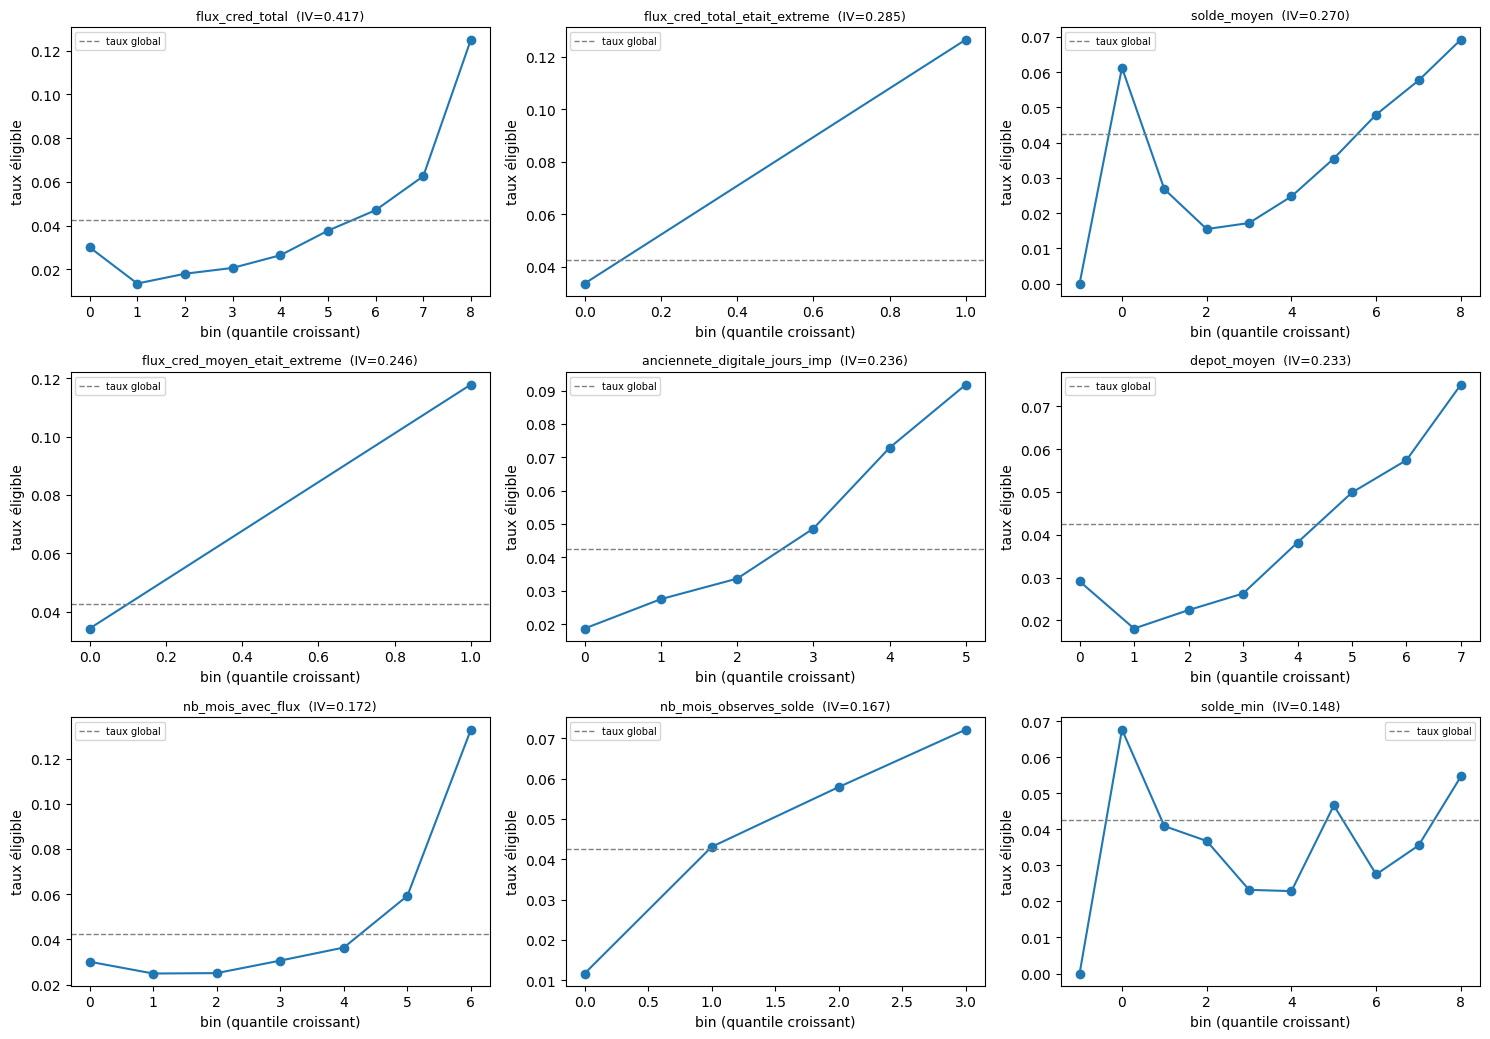

In [10]:
import matplotlib.pyplot as plt

top_iv_num = iv_num_df[iv_num_df["iv"] > 0.02].head(9)["feature"].tolist()
print(f"Features numériques avec IV > 0.02 (jusqu'à 9 affichées) : {top_iv_num}")

if top_iv_num:
    ncols = 3
    nrows = -(-len(top_iv_num) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, c in zip(axes, top_iv_num):
        d = detail_woe_num[c].sort_values("_bin")
        ax.plot(d["_bin"], d["taux_pos_bin"], marker="o")
        ax.axhline(taux_eligible, color="grey", linestyle="--", linewidth=1, label="taux global")
        ax.set_title(f"{c}  (IV={iv_num_df.set_index('feature').loc[c, 'iv']:.3f})", fontsize=9)
        ax.set_xlabel("bin (quantile croissant)")
        ax.set_ylabel("taux éligible")
        ax.legend(fontsize=7)
    for ax in axes[len(top_iv_num):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Aucune feature numérique au-dessus du seuil IV=0.02 -- passer directement à la section 3 "
          "(information mutuelle, peut révéler un signal que même le binning IV rate si la relation "
          "n'est pas monotone dans un sens que le binning en quantiles égaux capture bien).")


## 3. Information mutuelle — contrôle indépendant, sans hypothèse de forme

WOE/IV suppose un binning raisonnable ; l'information mutuelle (`sklearn.feature_selection.
mutual_info_classif`) ne suppose rien sur la forme de la relation. Calculée ici sur un
**échantillon stratifié** (garder le même taux de 4.6% de positifs que la population — un
échantillon aléatoire simple sur seulement 300k lignes garderait ~13800 positifs, largement
suffisant, mais on stratifie explicitement pour ne pas dépendre de la chance du tirage).

In [11]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

SAMPLE_N = 300_000
frac = min(1.0, SAMPLE_N / n_total)

# Échantillonnage stratifié : même fraction dans chaque classe, pas un sample() global
# qui pourrait par malchance sous-représenter la classe positive sur un tirage.
fractions = {0: frac, 1: frac}
pdf_mi = df.sampleBy(COL_LABEL, fractions=fractions, seed=RANDOM_SEED).toPandas()
print(f"Échantillon stratifié pour l'information mutuelle : {len(pdf_mi)} lignes, "
      f"{pdf_mi[COL_LABEL].mean():.2%} positifs (cible : {taux_eligible:.2%})")

mi_cols = num_cols + [c for c in cat_cols if c in pdf_mi.columns]
X_mi = pdf_mi[mi_cols].copy()

# Encodage minimal (ordinal) juste pour l'algorithme -- pas pour le modèle final, l'ordre
# arbitraire ne fausse pas l'information mutuelle comme il fausserait un modèle linéaire
cat_mi_cols = [c for c in cat_cols if c in X_mi.columns]
if cat_mi_cols:
    X_mi[cat_mi_cols] = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1).fit_transform(
        X_mi[cat_mi_cols].astype(str)
    )
X_mi = X_mi.fillna(X_mi.median(numeric_only=True)).fillna(-1)

discrete_mask = [c in cat_mi_cols for c in mi_cols]
mi_scores = mutual_info_classif(
    X_mi, pdf_mi[COL_LABEL], discrete_features=discrete_mask, random_state=RANDOM_SEED
)
mi_df = pd.DataFrame({"feature": mi_cols, "mutual_info": mi_scores}).sort_values(
    "mutual_info", ascending=False
).reset_index(drop=True)
print("\nInformation mutuelle vs label_eligibilite :")
display(mi_df)


Échantillon stratifié pour l'information mutuelle : 299892 lignes, 4.24% positifs (cible : 4.25%)

Information mutuelle vs label_eligibilite :


,feature,mutual_info
0,jamais_utilise_gab,0.047574
1,jamais_active_digital,0.037926
2,nb_mois_observes_solde,0.029983
3,solde_min_etait_extreme,0.024309
4,nb_mois_avec_flux,0.021089
5,recence_gab_jours_imp,0.017300
6,solde_volatilite_indefinie,0.015207
7,anciennete_digitale_jours_imp,0.014569
8,solde_moyen,0.011215
9,flux_cred_total,0.010552


## 4. Modèle-sonde (LightGBM + SHAP) — capture les interactions

Les trois sections précédentes restent **univariées** : chaque feature est jugée seule.
Un modèle d'arbres capture nativement les interactions (ex. `AGENCE` seule ne dit rien, mais
`AGENCE=X et TAILLE_ENTREPRI=PME` si) et les non-linéarités, sans qu'on ait à les deviner
à l'avance. On entraîne ici un LightGBM **volontairement simple** (peu d'arbres, profondeur
limitée) — l'objectif n'est pas la performance, c'est un instrument de mesure du signal
disponible, pas le modèle de production (celui-là reste dans `pipeline_fast_tuning`).

Sur le même échantillon stratifié que la section 3, pour rester cohérent.

In [12]:
!pip install shap

In [13]:
from lightgbm import LGBMClassifier
import shap

X_probe = X_mi.copy()  # même encodage que section 3, réutilisé
y_probe = pdf_mi[COL_LABEL].values
scale_pos_weight = (y_probe == 0).sum() / (y_probe == 1).sum()

modele_sonde = LGBMClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED,
    verbosity=-1,
)
modele_sonde.fit(X_probe, y_probe)

importance_df = pd.DataFrame({
    "feature": mi_cols,
    "importance_gain": modele_sonde.booster_.feature_importance(importance_type="gain"),
}).sort_values("importance_gain", ascending=False).reset_index(drop=True)
importance_df["importance_gain_pct"] = (
    importance_df["importance_gain"] / importance_df["importance_gain"].sum() * 100
).round(2)
print("Importance (gain) -- modèle-sonde LightGBM :")
display(importance_df)


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Importance (gain) -- modèle-sonde LightGBM :


,feature,importance_gain,importance_gain_pct
0,flux_cred_total,529033.514666,33.21
1,nb_mois_observes_solde,123336.874203,7.74
2,solde_min,122349.968704,7.68
3,depot_moyen,120235.581071,7.55
4,age_client,96194.881857,6.04
5,solde_moyen,73853.539608,4.64
6,pack_actuel,71607.017131,4.49
7,CUSTOMER_RATING,68341.895996,4.29
8,anciennete_digitale_jours_imp,63194.270281,3.97
9,solde_min_etait_extreme,41064.620184,2.58


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


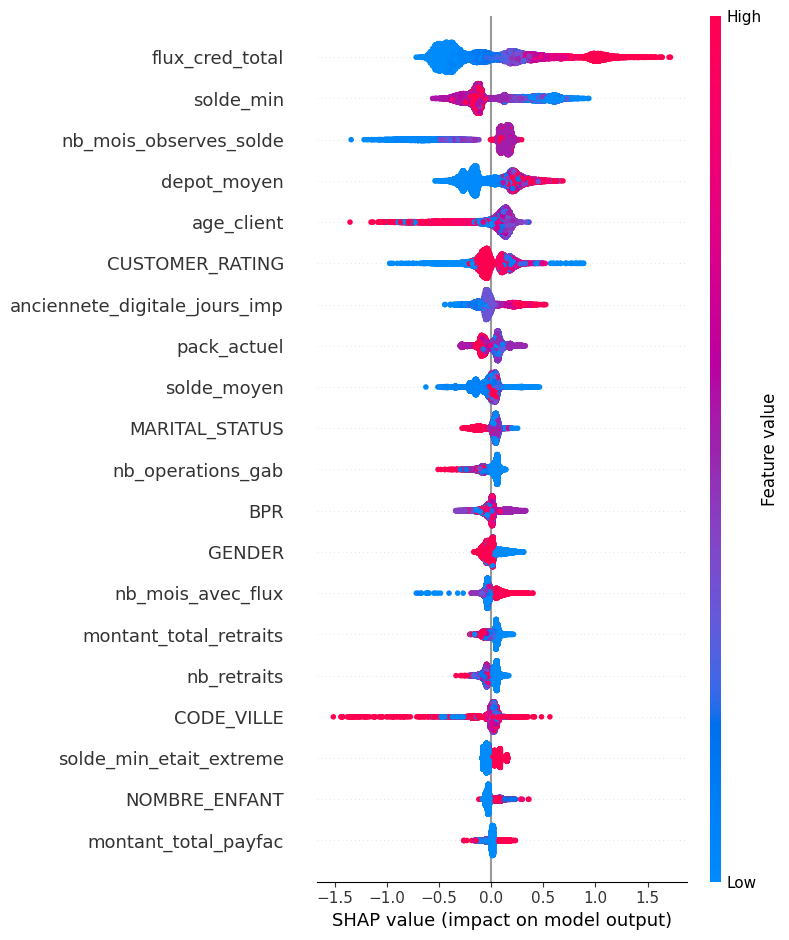


Importance SHAP (|valeur SHAP| moyenne, classe éligible) :


,feature,mean_abs_shap
0,flux_cred_total,0.419177
1,solde_min,0.268065
2,nb_mois_observes_solde,0.219856
3,depot_moyen,0.207982
4,age_client,0.177851
5,CUSTOMER_RATING,0.125712
6,anciennete_digitale_jours_imp,0.091678
7,pack_actuel,0.084311
8,solde_moyen,0.078915
9,MARITAL_STATUS,0.061357


In [14]:
# SHAP : direction de l'effet en plus de la magnitude (gain ne dit pas le sens),
# et base pour les interactions (section 5). Sur un sous-échantillon du sample pour rester
# rapide -- SHAP sur arbres est efficace mais TreeExplainer + 300k lignes reste inutilement long
# pour un instrument de diagnostic.
SHAP_SAMPLE_N = 20_000
idx_shap = np.random.RandomState(RANDOM_SEED).choice(len(X_probe), size=min(SHAP_SAMPLE_N, len(X_probe)), replace=False)
X_shap = X_probe.iloc[idx_shap]

explainer = shap.TreeExplainer(modele_sonde)
shap_values = explainer.shap_values(X_shap)
# LightGBM binaire : shap_values peut être une liste [classe0, classe1] ou un array direct
# selon la version -- normaliser sur la classe positive
sv_classe1 = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv_classe1, X_shap, show=False)
plt.tight_layout()
plt.show()

shap_importance = pd.DataFrame({
    "feature": mi_cols,
    "mean_abs_shap": np.abs(sv_classe1).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
print("\nImportance SHAP (|valeur SHAP| moyenne, classe éligible) :")
display(shap_importance)


## 5. Interactions explicites — paires dont l'effet combiné dépasse la somme des effets seuls

`SHAP interaction values` isole, pour chaque paire de features, la part de l'effet qui
n'est PAS explicable par les deux effets marginaux pris séparément. Coûteux (O(n_features²)
par ligne) — limité aux 8 features les plus importantes (section 4) et à un sous-échantillon
plus petit.

In [15]:
TOP_N_INTERACTIONS = 8
top_features_interaction = importance_df.head(TOP_N_INTERACTIONS)["feature"].tolist()
INTERACTION_SAMPLE_N = 5_000

idx_inter = np.random.RandomState(RANDOM_SEED).choice(len(X_probe), size=min(INTERACTION_SAMPLE_N, len(X_probe)), replace=False)
X_inter = X_probe.iloc[idx_inter][mi_cols]  # garder toutes les colonnes, l'explainer attend le même schema

interaction_values = explainer.shap_interaction_values(X_inter)
iv_classe1 = interaction_values[1] if isinstance(interaction_values, list) else interaction_values

# Moyenne de |interaction| hors diagonale (diagonale = effet principal, pas une interaction)
mean_abs_interaction = np.abs(iv_classe1).mean(axis=0)
np.fill_diagonal(mean_abs_interaction, 0)

idx_top = [mi_cols.index(c) for c in top_features_interaction]
sub = mean_abs_interaction[np.ix_(idx_top, idx_top)]
interaction_pairs = []
for i in range(len(idx_top)):
    for j in range(i + 1, len(idx_top)):
        interaction_pairs.append({
            "feature_1": top_features_interaction[i],
            "feature_2": top_features_interaction[j],
            "force_interaction": sub[i, j],
        })
interaction_df = pd.DataFrame(interaction_pairs).sort_values("force_interaction", ascending=False).reset_index(drop=True)
print("Paires avec la plus forte interaction (parmi le top features du modèle-sonde) :")
display(interaction_df)


Paires avec la plus forte interaction (parmi le top features du modèle-sonde) :


,feature_1,feature_2,force_interaction
0,solde_min,depot_moyen,0.043512
1,solde_min,solde_moyen,0.040411
2,flux_cred_total,depot_moyen,0.037599
3,flux_cred_total,solde_min,0.027933
4,flux_cred_total,nb_mois_observes_solde,0.027434
5,age_client,CUSTOMER_RATING,0.016493
6,solde_min,pack_actuel,0.014993
7,depot_moyen,age_client,0.014506
8,flux_cred_total,pack_actuel,0.013981
9,nb_mois_observes_solde,age_client,0.013245


In [16]:
# Grille croisée pour la paire la plus forte -- rend l'interaction lisible sans SHAP,
# à montrer/valider avec un métier plutôt qu'une seule valeur abstraite
if len(interaction_df) > 0:
    f1, f2 = interaction_df.iloc[0][["feature_1", "feature_2"]]
    print(f"Grille croisée : {f1} x {f2}\n(taux d'éligibilité par cellule, binné en 4 quantiles chacun)")

    d = pdf_mi[[f1, f2, COL_LABEL]].copy()
    for f in (f1, f2):
        if pd.api.types.is_numeric_dtype(d[f]):
            d[f + "_bin"] = pd.qcut(d[f], 4, duplicates="drop")
        else:
            d[f + "_bin"] = d[f]
    pivot = d.pivot_table(index=f1 + "_bin", columns=f2 + "_bin", values=COL_LABEL, aggfunc="mean")
    display(pivot.style.background_gradient(cmap="RdYlGn", axis=None).format("{:.2%}"))


Grille croisée : solde_min x depot_moyen
(taux d'éligibilité par cellule, binné en 4 quantiles chacun)


depot_moyen_bin,"(-0.001, 41.638]","(41.638, 1800.036]","(1800.036, 18904.577]","(18904.577, 46887.721]"
solde_min_bin,,,,
"(-1055.3509999999999, -329.85]",4.53%,4.51%,7.62%,10.69%
"(-329.85, -6.165]",1.20%,1.85%,3.93%,5.91%
"(-6.165, 177.66]",0.52%,1.49%,4.21%,7.30%
"(177.66, 859.61]",0.85%,1.43%,4.22%,6.67%


## 6. Analyse des erreurs du modèle actuel — patterns dans ce qu'il rate

Les sections 1-5 cherchent le signal dans les données brutes. Celle-ci cherche le signal dans
ce que le **modèle actuel** (XGBoost, F1 classe 1 = 0.26, checkpoint `pipeline_fast_tuning`
section 10) rate déjà — souvent plus actionnable : si les faux négatifs partagent un profil
(ex. tous dans une tranche d'âge, ou tous avec `pack_actuel` absent), c'est soit une feature
manquante, soit une interaction que le modèle actuel n'exploite pas encore.

In [17]:
import joblib

# Recharge l'encodeur + le modèle sklearn du meilleur candidat connu (cf. pipeline
# section 10 -- adapter le chemin si le nom de checkpoint diffère chez vous)
try:
    xgb_model = joblib.load(f"{XGB_CHECKPOINT_PATH}/XGBoost.joblib")
    xgb_meta = joblib.load(f"{XGB_CHECKPOINT_PATH}/XGBoost_meta.joblib")
    seuil_xgb = xgb_meta["seuil_decision"]
    print(f"Modèle XGBoost rechargé, seuil de décision retenu : {seuil_xgb:.3f}")
except Exception as e:
    print(f"Impossible de recharger le checkpoint XGBoost ({e}) -- adapter XGB_CHECKPOINT_PATH "
          f"ci-dessus, ou passer cette section si aucun modèle n'est encore entraîné sur v2.")
    xgb_model = None

if xgb_model is not None:
    proba = xgb_model.predict_proba(X_probe)[:, 1]
    pred = (proba >= seuil_xgb).astype(int)

    pdf_mi["_pred"] = pred
    pdf_mi["_proba"] = proba
    faux_negatifs = pdf_mi[(pdf_mi[COL_LABEL] == 1) & (pdf_mi["_pred"] == 0)]
    vrais_positifs = pdf_mi[(pdf_mi[COL_LABEL] == 1) & (pdf_mi["_pred"] == 1)]
    print(f"Faux négatifs dans l'échantillon : {len(faux_negatifs)} / {(pdf_mi[COL_LABEL]==1).sum()} positifs "
          f"({len(faux_negatifs) / max(1,(pdf_mi[COL_LABEL]==1).sum()):.1%} des positifs sont ratés)")


Impossible de recharger le checkpoint XGBoost ([Errno 2] No such file or directory: './models_checkpoint/XGBoost_meta.joblib') -- adapter XGB_CHECKPOINT_PATH ci-dessus, ou passer cette section si aucun modèle n'est encore entraîné sur v2.


Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.


In [18]:
if xgb_model is not None and len(faux_negatifs) > 20:
    # Comparaison des faux négatifs (positifs ratés) vs vrais positifs (positifs bien détectés)
    # sur les features les plus importantes -- révèle le profil que le modèle actuel ne voit pas
    cols_a_comparer = top_features_interaction  # top 8 du modèle-sonde, section 4

    comparaison = pd.DataFrame({
        "moyenne_faux_negatifs": faux_negatifs[cols_a_comparer].mean(),
        "moyenne_vrais_positifs": vrais_positifs[cols_a_comparer].mean(),
    })
    comparaison["ecart_relatif"] = (
        (comparaison["moyenne_faux_negatifs"] - comparaison["moyenne_vrais_positifs"])
        / comparaison["moyenne_vrais_positifs"].replace(0, np.nan)
    )
    print("Profil des positifs RATÉS par le modèle actuel vs positifs bien détectés :")
    display(comparaison.sort_values("ecart_relatif", key=abs, ascending=False))
    print("\nUn écart relatif marqué sur une feature = zone où le modèle actuel sous-utilise "
          "le signal disponible -- candidat prioritaire pour la section 8 (feature engineering).")


## 6bis. Analyse des segments — le modèle actuel est-il bon partout, ou seulement sur certains clients ?

Dernière pièce du flux, demandée après relecture de v4 : les sections 4/5/6 regardent quelles
*features* comptent et où le modèle se trompe sur des *clients individuels* -- cette section regarde
si sa performance est stable *entre sous-populations*. Un F1 global bas peut cacher un modèle
correct sur un segment et quasi inutile sur un autre ; dans ce cas le prochain gain ne vient ni d'une
nouvelle feature globale ni d'un nouvel algorithme, mais d'un traitement différencié par segment
(feature spécifique, seuil de décision par segment, ou modèle séparé -- même logique que le
multiclasse par produit proposé section 1.6, mais sur un axe client plutôt que produit).

Segments testés, choisis pour croiser avec les cross-features fortes trouvées section 1.5 :
activité digitale (`jamais_active_digital`), tranche d'âge, `CUSTOMER_RATING`, `pack_actuel`,
`TAILLE_ENTREPRI`.

In [19]:
if xgb_model is not None:
    from sklearn.metrics import precision_score, recall_score, f1_score

    pdf_seg = pdf_mi.copy()
    pdf_seg["_age_bucket"] = pd.cut(
        pdf_seg["age_client"], bins=[0, 30, 45, 60, 200],
        labels=["<30", "30-45", "45-60", "60+"]
    )
    pdf_seg["_digital"] = np.where(pdf_seg["jamais_active_digital"] == 1, "jamais_digital", "deja_digital")

    SEGMENTS_A_TESTER = {
        "activite_digitale": "_digital",
        "tranche_age": "_age_bucket",
        "customer_rating": "CUSTOMER_RATING",
        "pack_actuel": "pack_actuel",
        "taille_entreprise": "TAILLE_ENTREPRI",
    }

    MIN_POSITIFS_SEGMENT = 15  # sous ce seuil, precision/recall/F1 par segment sont trop bruités pour être lus

    f1_global = f1_score(pdf_seg[COL_LABEL], pdf_seg["_pred"])
    print(f"F1 global (rappel) sur cet échantillon : {f1_global:.3f}\n")

    resultats_segments = []
    for nom_segment, col_segment in SEGMENTS_A_TESTER.items():
        for modalite, sous_groupe in pdf_seg.groupby(col_segment, observed=True):
            n_pos = (sous_groupe[COL_LABEL] == 1).sum()
            if n_pos < MIN_POSITIFS_SEGMENT:
                continue
            resultats_segments.append({
                "segment": nom_segment,
                "modalite": modalite,
                "n": len(sous_groupe),
                "n_pos": n_pos,
                "taux_pos": n_pos / len(sous_groupe),
                "precision": precision_score(sous_groupe[COL_LABEL], sous_groupe["_pred"], zero_division=0),
                "recall": recall_score(sous_groupe[COL_LABEL], sous_groupe["_pred"], zero_division=0),
                "f1": f1_score(sous_groupe[COL_LABEL], sous_groupe["_pred"], zero_division=0),
            })

    segments_df = pd.DataFrame(resultats_segments).sort_values("f1", ascending=False).reset_index(drop=True)
    segments_df["ecart_vs_global"] = segments_df["f1"] - f1_global
    print(f"Performance par segment (modalités avec >= {MIN_POSITIFS_SEGMENT} positifs) :")
    display(segments_df)

    ecart_max = segments_df["ecart_vs_global"].abs().max()
    if ecart_max > 0.10:
        pire = segments_df.sort_values("f1").iloc[0]
        meilleur = segments_df.sort_values("f1", ascending=False).iloc[0]
        print(f"\nÉcart significatif détecté (> 0.10 de F1) entre segments -- ex. "
              f"{meilleur['segment']}={meilleur['modalite']} (F1={meilleur['f1']:.3f}) vs "
              f"{pire['segment']}={pire['modalite']} (F1={pire['f1']:.3f}). "
              f"Le modèle n'est pas également mauvais partout : prioriser un traitement spécifique "
              f"sur le(s) segment(s) le(s) plus faible(s) plutôt qu'une feature générique de plus.")
    else:
        print(f"\nÉcart maximum entre segments : {ecart_max:.3f} -- pas de sous-population isolée "
              f"nettement plus facile/difficile ; le plafond de F1 semble uniforme, cohérent avec un "
              f"problème de périmètre de données (section 10) plutôt que de segmentation client.")
else:
    print("Section sautée : nécessite xgb_model chargé en section 6.")

Section sautée : nécessite xgb_model chargé en section 6.


## 7. Classement unifié — fusion IV / MI / importance modèle

Chaque méthode a son échelle propre (IV n'est pas comparable à un score d'information mutuelle
en nats, ni à un gain LightGBM) — on fusionne donc par **rang**, pas par valeur brute, ce qui
rend les méthodes comparables et réduit le risque de sur-pondérer une méthode juste parce que
son échelle numérique produit de plus grandes valeurs.

In [20]:
def to_rank(df_scores: pd.DataFrame, feature_col: str, score_col: str) -> pd.Series:
    return df_scores.set_index(feature_col)[score_col].rank(ascending=False)

iv_all = pd.concat([
    iv_num_df.rename(columns={"iv": "iv"})[["feature", "iv"]],
    iv_cat_df.rename(columns={"iv": "iv"})[["feature", "iv"]],
]).set_index("feature")["iv"]

rang_iv = iv_all.rank(ascending=False)
rang_mi = to_rank(mi_df, "feature", "mutual_info")
rang_importance = to_rank(importance_df, "feature", "importance_gain")
rang_shap = to_rank(shap_importance, "feature", "mean_abs_shap")

classement = pd.DataFrame({
    "iv": iv_all, "rang_iv": rang_iv,
    "mutual_info": mi_df.set_index("feature")["mutual_info"], "rang_mi": rang_mi,
    "importance_gain": importance_df.set_index("feature")["importance_gain"], "rang_importance": rang_importance,
    "mean_abs_shap": shap_importance.set_index("feature")["mean_abs_shap"], "rang_shap": rang_shap,
})
classement["rang_moyen"] = classement[["rang_iv", "rang_mi", "rang_importance", "rang_shap"]].mean(axis=1)
classement = classement.sort_values("rang_moyen")

print("Classement unifié (rang moyen sur les 4 méthodes -- plus petit = plus important) :")
display(classement)

print("\nFeatures suspectes (IV > 0.5 -- vérifier une fuite de données avant de les garder) :")
display(classement[classement["iv"] > 0.5])


Classement unifié (rang moyen sur les 4 méthodes -- plus petit = plus important) :


,iv,rang_iv,mutual_info,rang_mi,importance_gain,rang_importance,mean_abs_shap,rang_shap,rang_moyen
feature,,,,,,,,,
flux_cred_total,0.417056,1.0,0.010552,10.0,529033.514666,1.0,0.419177,1.0,3.250000
nb_mois_observes_solde,0.167495,10.0,0.029983,3.0,123336.874203,2.0,0.219856,3.0,4.500000
solde_min,0.148205,11.0,0.009727,11.0,122349.968704,3.0,0.268065,2.0,6.750000
depot_moyen,0.233275,7.0,0.009466,12.0,120235.581071,4.0,0.207982,4.0,6.750000
solde_moyen,0.269977,4.0,0.011215,9.0,73853.539608,6.0,0.078915,9.0,7.000000
CUSTOMER_RATING,0.375623,2.0,0.008314,13.0,68341.895996,8.0,0.125712,6.0,7.250000
anciennete_digitale_jours_imp,0.235562,6.0,0.014569,8.0,63194.270281,9.0,0.091678,7.0,7.500000
pack_actuel,0.222337,8.0,0.004940,19.0,71607.017131,7.0,0.084311,8.0,10.500000
age_client,0.127474,13.0,0.003683,20.0,96194.881857,5.0,0.177851,5.0,10.750000



Features suspectes (IV > 0.5 -- vérifier une fuite de données avant de les garder) :


,iv,rang_iv,mutual_info,rang_mi,importance_gain,rang_importance,mean_abs_shap,rang_shap,rang_moyen
feature,,,,,,,,,


## 8. Feature engineering dérivé des patterns trouvés

Quatre familles de colonnes ajoutées, chacune justifiée par une section précédente précise --
pas d'ajout spéculatif :

- **Ratio pour chaque paire redondante** (section 1quater) : pour toute paire `|corr| > 0.6`
  détectée sur la vraie population, on garde le compteur (`nb_...`) et on remplace le total
  brut par un ratio (`montant_moyen_...`) -- l'information du total redondant n'est pas
  perdue (le compteur + le ratio permettent de la reconstruire), mais le modèle ne voit plus
  deux colonnes qui portent presque le même signal.
- **Binning des features non-monotones** (section 2) : un modèle linéaire ne capte pas un
  U-shape, mais un modèle d'arbres (RandomForest/XGBoost/LightGBM, déjà utilisés) le capte
  nativement -- donc pas nécessaire pour eux. Créé quand même en variable catégorielle pour
  les cas où le bin lui-même porte un sens métier plus lisible qu'un seuil implicite d'arbre.
- **Interaction explicite** (section 5) : la paire la plus forte, matérialisée en colonne
  concaténée -- un `StringIndexer + OneHotEncoder` dessus donne au modèle un accès direct à
  la cellule de la grille croisée, sans compter sur la profondeur d'arbre pour la retrouver.
- **Regroupement de `CODE_VILLE`** (section 1bis) : la version regroupée (`AUTRE` pour les
  villes à faible effectif) remplace la version brute dans les features -- moins de bruit
  d'échantillonnage, IV plus fiable.


In [21]:
df_v3 = df_ville_regroupee

# --- Ratios pour les paires redondantes (section 1quater) : pour chaque paire, on suppose
#     que la variable au vocabulaire "montant_total_*"/"total_*" est le numérateur et la
#     variable "nb_*"/"count*" est le dénominateur -- à corriger manuellement ci-dessous si
#     une paire détectée ne suit pas cette convention de nommage. ---
# CORRECTIF (bug identifié après relecture) : la convention de nommage seule ne dit rien
# du pouvoir prédictif. Sur la paire flux_cred_total / nb_mois_avec_flux (corr=0.64),
# "flux_cred_total" tombait côté "numer" par pur hasard de nommage et était donc DROPPÉ
# du feature set section 9 -- alors que c'est la feature #1 de tout le classement (IV=0.417,
# #1 en gain LightGBM, #1 en SHAP). Le ratio créé (flux_cred_total_moyen) ne remplace pas
# un signal aussi fort tout seul. Garde-fou : si `numer` a déjà un IV fort en soi
# (>= SEUIL_IV_PROTEGE), on crée quand même le ratio, mais on NE DROPPE PAS `numer`.
SEUIL_IV_PROTEGE = 0.1  # "Moyen" et au-dessus sur la grille section 1 -- trop fort pour être juste un total redondant

COLONNES_REDONDANTES_DROPPEES = []
RATIOS_CREES = {}
for _, row in paires_redondantes.iterrows():
    v1, v2 = row["variable_1"], row["variable_2"]
    if v1.startswith(("nb_", "count")) and not v2.startswith(("nb_", "count")):
        denom, numer = v1, v2
    elif v2.startswith(("nb_", "count")) and not v1.startswith(("nb_", "count")):
        denom, numer = v2, v1
    else:
        print(f"  (paire {v1} / {v2} : convention de nommage ambiguë -- pas de ratio auto-créé, à traiter manuellement)")
        continue
    nouveau_nom = f"{numer}_moyen"
    df_v3 = df_v3.withColumn(
        nouveau_nom,
        F.when(F.col(denom) > 0, F.col(numer) / F.col(denom)).otherwise(F.lit(0.0))
    )
    RATIOS_CREES[nouveau_nom] = (numer, denom)

    iv_numer = classement.loc[numer, "iv"] if numer in classement.index else 0.0
    if iv_numer >= SEUIL_IV_PROTEGE:
        print(f"  (paire {numer} / {denom} : ratio {nouveau_nom} créé, mais {numer} CONSERVÉ tel quel "
              f"-- IV={iv_numer:.3f} >= {SEUIL_IV_PROTEGE}, trop fort pour être traité comme un total redondant)")
    else:
        COLONNES_REDONDANTES_DROPPEES.append(numer)

print(f"Ratios créés : {list(RATIOS_CREES.keys())}")
print(f"Colonnes totales redondantes marquées à dropper du feature set "
      f"(gardées dans le dataset, juste exclues de feature_cols) : {COLONNES_REDONDANTES_DROPPEES}")

# --- Interaction explicite (paire la plus forte, section 5) ---
# CORRECTIF (bug identifié après relecture) : concaténer les deux valeurs brutes en string
# ("1487.32__205.0") produit une colonne quasi-unique (1.66M valeurs distinctes / 3.17M
# lignes observées) -- pas une interaction, un fingerprint client. Côté pipeline, le
# cast("double") appliqué à cette colonne (nécessaire pour éviter le crash Kryo sur un
# type string à trop haute cardinalité) ne lève pas d'erreur : il renvoie null pour toute
# chaîne non parseable en nombre, donc null sur la quasi-totalité des lignes -- et
# VectorAssembler(handleInvalid="skip") droppe ensuite toute ligne où un input assemblé
# est null. Résultat : entraînement sur un DataFrame quasi vide, silencieusement.
# Fix : binner f1 et f2 en quartiles AVANT de combiner (4x4 = 16 cellules max, une vraie
# variable catégorielle de basse cardinalité -- même intention que la grille croisée
# section 5, matérialisée en colonne).
if len(interaction_df) > 0:
    f1, f2 = interaction_df.iloc[0][["feature_1", "feature_2"]]
    nouvelle_col = f"interaction_{f1}_x_{f2}"

    bornes_f1 = df_v3.approxQuantile(f1, [0.25, 0.5, 0.75], 0.01)
    bornes_f2 = df_v3.approxQuantile(f2, [0.25, 0.5, 0.75], 0.01)

    def bin_expr(col, bornes):
        return sum([F.when(F.col(col) > b, 1).otherwise(0) for b in bornes])

    df_v3 = df_v3.withColumn(
        nouvelle_col,
        (bin_expr(f1, bornes_f1) * 4 + bin_expr(f2, bornes_f2)).cast("string")
    )
    print(f"Colonne d'interaction créée : {nouvelle_col} "
          f"({df_v3.select(nouvelle_col).distinct().count()} valeurs distinctes -- "
          f"catégorielle, PAS numérique : à ajouter à cols_categorielles côté pipeline, "
          f"jamais à cast('double'))")
else:
    nouvelle_col = None

# --- Binning des features non-monotones identifiées section 2 (à ajuster selon ce que les graphes montrent) ---
FEATURES_A_BINNER = top_iv_num  # défini section 2 -- affiner manuellement après lecture des graphes
for c in FEATURES_A_BINNER:
    bornes = df_v3.approxQuantile(c, [0.25, 0.5, 0.75], 0.01)
    bornes = sorted(set(bornes))
    if len(bornes) < 2:
        continue
    df_v3 = df_v3.withColumn(
        f"{c}_bin",
        F.when(F.col(c).isNull(), "inconnu").otherwise(
            sum([F.when(F.col(c) > b, 1).otherwise(0) for b in bornes]).cast("string")
        )
    )
print(f"Colonnes binnées créées pour : {FEATURES_A_BINNER}")


  (paire montant_moyen_gab / montant_moyen_gab_etait_extreme : convention de nommage ambiguë -- pas de ratio auto-créé, à traiter manuellement)
  (paire flux_cred_moyen_etait_extreme / flux_cred_total_etait_extreme : convention de nommage ambiguë -- pas de ratio auto-créé, à traiter manuellement)
  (paire depot_moyen / depot_moyen_etait_extreme : convention de nommage ambiguë -- pas de ratio auto-créé, à traiter manuellement)
  (paire montant_total_gab / montant_moyen_gab : convention de nommage ambiguë -- pas de ratio auto-créé, à traiter manuellement)
  (paire solde_moyen / solde_moyen_etait_extreme : convention de nommage ambiguë -- pas de ratio auto-créé, à traiter manuellement)
  (paire montant_total_retraits / nb_retraits : ratio montant_total_retraits_moyen créé, mais montant_total_retraits CONSERVÉ tel quel -- IV=0.103 >= 0.1, trop fort pour être traité comme un total redondant)
  (paire montant_total_payfac / nb_paiements_digitaux : ratio montant_total_payfac_moyen créé, mais 

Colonne d'interaction créée : interaction_solde_min_x_depot_moyen (16 valeurs distinctes -- catégorielle, PAS numérique : à ajouter à cols_categorielles côté pipeline, jamais à cast('double'))


Colonnes binnées créées pour : ['flux_cred_total', 'flux_cred_total_etait_extreme', 'solde_moyen', 'flux_cred_moyen_etait_extreme', 'anciennete_digitale_jours_imp', 'depot_moyen', 'nb_mois_avec_flux', 'nb_mois_observes_solde', 'solde_min']


## 9. Config de features v3 — versionnée, écrite pour le pipeline

In [22]:
SEUIL_IV_MINIMUM = 0.02  # sous ce seuil : feature jugée sans pouvoir prédictif, cf. grille section 1

features_retenues_num = classement[
    (classement["iv"] >= SEUIL_IV_MINIMUM) & (classement.index.isin(num_cols))
].index.tolist()
# Retire les totaux redondants (section 1quater) -- remplacés par leur ratio, pas doublés
features_retenues_num = [c for c in features_retenues_num if c not in COLONNES_REDONDANTES_DROPPEES]
features_retenues_num += list(RATIOS_CREES.keys())

features_retenues_cat = classement[
    (classement["iv"] >= SEUIL_IV_MINIMUM) & (classement.index.isin(cat_cols))
].index.tolist()
# CORRECTIF : colonne_interaction est une string de basse cardinalité (16 cellules max
# après binning, section 8) -- elle n'apparaît pas dans `classement` (créée après le calcul
# d'IV) donc ne serait routée nulle part sans cette ligne. Elle doit aller dans les features
# catégorielles (StringIndexer + OneHotEncoder côté pipeline), jamais dans les numériques.
if nouvelle_col is not None and nouvelle_col not in features_retenues_cat:
    features_retenues_cat = features_retenues_cat + [nouvelle_col]
features_suspectes_iv_elevee = classement[classement["iv"] > 0.5].index.tolist()

FEATURE_CONFIG_V3 = {
    "col_label": COL_LABEL,
    "cols_categorielles_basse_cardinalite": features_retenues_cat,
    "col_haute_cardinalite": f"{COL_HAUTE_CARDINALITE}_regroupe",
    "cols_numeriques": features_retenues_num,
    "cols_a_exclure_des_features": list(COLS_A_EXCLURE),
    "colonne_interaction": nouvelle_col,
    "colonnes_binnees": [f"{c}_bin" for c in FEATURES_A_BINNER],
    "cols_numeriques_ratios_ajoutees": list(RATIOS_CREES.keys()),
    "cols_numeriques_dropped_redondantes": COLONNES_REDONDANTES_DROPPEES,
    "features_suspectes_iv_superieur_0_5": features_suspectes_iv_elevee,
    "seuil_iv_minimum_applique": SEUIL_IV_MINIMUM,
    "classement_complet": classement.reset_index().rename(columns={"index": "feature"}).to_dict(orient="records"),
}

print(json.dumps({k: v for k, v in FEATURE_CONFIG_V3.items() if k != "classement_complet"},
                  indent=2, ensure_ascii=False))
print(f"\n{len(features_retenues_num)} features numériques + {len(features_retenues_cat)} catégorielles "
      f"retenues (IV >= {SEUIL_IV_MINIMUM}), sur {len(num_cols) + len(cat_cols)} candidates initiales.")
if features_suspectes_iv_elevee:
    print(f"\nATTENTION -- à vérifier avant tout entraînement : {features_suspectes_iv_elevee} "
          f"ont un IV > 0.5, ce qui est plus souvent une fuite de données qu'un vrai signal "
          f"(ex. une colonne dérivée après coup du label, ou un identifiant déguisé).")


{
  "col_label": "label_eligibilite",
  "cols_categorielles_basse_cardinalite": [
    "CUSTOMER_RATING",
    "pack_actuel",
    "MARITAL_STATUS",
    "NOMBRE_ENFANT",
    "pack_etat",
    "interaction_solde_min_x_depot_moyen"
  ],
  "col_haute_cardinalite": "CODE_VILLE_regroupe",
  "cols_numeriques": [
    "flux_cred_total",
    "nb_mois_observes_solde",
    "solde_min",
    "depot_moyen",
    "solde_moyen",
    "anciennete_digitale_jours_imp",
    "age_client",
    "nb_mois_avec_flux",
    "solde_min_etait_extreme",
    "montant_total_retraits",
    "montant_total_payfac",
    "jamais_active_digital",
    "solde_max_etait_extreme",
    "flux_cred_moyen_etait_extreme",
    "nb_retraits",
    "solde_volatilite_relative_imp",
    "nb_paiements_digitaux",
    "solde_moyen_etait_extreme",
    "flux_cred_total_etait_extreme",
    "depot_moyen_etait_extreme",
    "montant_total_retraits_moyen",
    "montant_total_payfac_moyen",
    "montant_total_vignette_moyen",
    "flux_cred_total_moyen",

In [23]:
# ═══ MEILLEURE_CROSS & Cross-Features catégorielles explicites ═══
# Ajout explicite des paires catégorielles à fort pouvoir prédictif (IV = 0.527)
cross_features = ["pack_actuel_x_CUSTOMER_RATING", "pack_etat_x_CUSTOMER_RATING", "pack_actuel_x_pack_etat"]

for cf in cross_features:
    p1, p2 = cf.split("_x_")
    if p1 in df_v3.columns and p2 in df_v3.columns:
        df_v3 = df_v3.withColumn(cf, F.concat_ws("__", F.col(p1), F.col(p2)))
        if cf not in FEATURE_CONFIG_V3["cols_categorielles_basse_cardinalite"]:
            FEATURE_CONFIG_V3["cols_categorielles_basse_cardinalite"].append(cf)
        print(f"Cross-feature ajoutée à df_v3 et config : {cf}")

# Ratios financiers additionnels
ratios_sup = {
    "ratio_retraits_flux_mois": ("montant_total_retraits", "nb_mois_avec_flux"),
    "ratio_flux_mois": ("flux_cred_total", "nb_mois_avec_flux"),
    "ratio_volatilite_solde": ("solde_volatilite_relative_imp", "solde_moyen"),
    "ratio_solde_age": ("solde_moyen", "age_client")
}

for r_name, (num, den) in ratios_sup.items():
    if num in df_v3.columns and den in df_v3.columns:
        df_v3 = df_v3.withColumn(
            r_name,
            F.when(F.col(den) > 0, F.col(num) / F.col(den)).otherwise(F.lit(0.0))
        )
        if r_name not in FEATURE_CONFIG_V3["cols_numeriques"]:
            FEATURE_CONFIG_V3["cols_numeriques"].append(r_name)
        print(f"Ratio additionnel créé et ajouté à la config : {r_name}")


Cross-feature ajoutée à df_v3 et config : pack_actuel_x_CUSTOMER_RATING
Cross-feature ajoutée à df_v3 et config : pack_etat_x_CUSTOMER_RATING
Cross-feature ajoutée à df_v3 et config : pack_actuel_x_pack_etat
Ratio additionnel créé et ajouté à la config : ratio_retraits_flux_mois
Ratio additionnel créé et ajouté à la config : ratio_flux_mois
Ratio additionnel créé et ajouté à la config : ratio_volatilite_solde
Ratio additionnel créé et ajouté à la config : ratio_solde_age


In [24]:
print(f"Écriture dataset enrichi v3 : {PATH_OUT_ENRICHED}")
df_v3.write.mode("overwrite").parquet(PATH_OUT_ENRICHED)
print("OK.")
config_json = json.dumps(FEATURE_CONFIG_V3, indent=2, ensure_ascii=False)
print(f"Écriture config features v3 : {FEATURE_CONFIG_OUT}")

# saveAsTextFile n'a pas d'option overwrite -- on supprime le chemin cible s'il existe déjà
hadoop_conf = spark._jsc.hadoopConfiguration()
path_jvm = spark._jvm.org.apache.hadoop.fs.Path(FEATURE_CONFIG_OUT)
fs = path_jvm.getFileSystem(hadoop_conf)
if fs.exists(path_jvm):
    fs.delete(path_jvm, True)

spark.sparkContext.parallelize([config_json], 1).saveAsTextFile(FEATURE_CONFIG_OUT)
print("OK.")

Écriture dataset enrichi v3 : s3a://processed-data/dataset_eligibilite_features_v3/


OK.
Écriture config features v3 : s3a://ml-scoring/models/feature_config_v3.json


OK.


## 10. Limites -- honnête

- **Le modèle-sonde (section 4) et l'analyse d'interactions (section 5) tournent sur un
  échantillon de 300k / 5-20k lignes**, pas la population complète -- nécessaire pour SHAP
  (non distribué), mais à garder en tête : une interaction réelle mais rare pourrait être
  sous-représentée dans l'échantillon.
- **L'analyse d'erreurs (section 6) dépend du modèle XGBoost déjà entraîné** -- si son seuil
  de décision ou ses hyperparamètres changent, les profils de faux négatifs changent aussi.
  À relancer après tout réentraînement significatif.
- **Toujours aucune donnée de sollicitation commerciale / ancienneté de relation bancaire**
  (déjà signalé dans la conclusion d'`EDA_ultimate`, section 17) -- si le classement de la
  section 7 reste faible sur toutes les features malgré WOE/IV + MI + modèle-sonde, c'est la
  confirmation la plus forte possible que le plafond de F1 est un problème de **périmètre
  de données**, pas de méthode d'EDA.
- Les features suspectes IV > 0.5 (section 9) DOIVENT être vérifiées manuellement (origine
  de la colonne, date de calcul vs date du label) avant tout entraînement -- une IV aussi
  élevée sur un problème à 4.6% de positifs est plus souvent le signe d'une fuite que d'un
  signal légitime.

## 11. Prochaine étape -- pointer `pipeline_fast_tuning` ici

Dans `pipeline_fast_tuning_v1_4_fixed.ipynb`, section 1 :
```python
PATH_TRAIN_IN = "s3a://processed-data/dataset_eligibilite_features_v3/"
```
et charger `FEATURE_CONFIG_OUT` (section 9 ci-dessus) au lieu des listes en dur de la
section 1 -- `cols_categorielles_basse_cardinalite`, `col_haute_cardinalite` (utiliser la
version `_regroupe`), et ajouter `colonne_interaction` + `colonnes_binnees` +
`cols_numeriques_ratios_ajoutees` (section 1.5) aux features du pipeline.

Sur le déséquilibre lui-même (au-delà des features) : si le classement section 7 montre un
signal réel (IV moyen > 0.05 sur le top 10), la prochaine amélioration côté modèle plutôt
que données est le calibrage du seuil de décision par validation croisée stratifiée (déjà
fait pour XGBoost/LightGBM en section 10 du pipeline, à étendre à RandomForest/LogReg qui
utilisent encore le seuil 0.5 par défaut de MLlib) plutôt qu'un nouveau sur-échantillonnage --
la pondération racine-carrée (pipeline section 5) a déjà été calibrée pour éviter la
sur-correction observée avec la pondération inverse-fréquence brute.


In [25]:
features_a_verifier = [
    "jamais_utilise_gab",
    "jamais_active_digital",
    "nb_mois_observes_solde",
    "nb_mois_avec_flux",
    "recence_gab_jours_imp",
    "anciennete_digitale_jours_imp",
    "solde_min_etait_extreme",
]

for f in features_a_verifier:
    print(f"{f:<35} {'✅' if f in df.columns else '❌'}")

jamais_utilise_gab                  ✅
jamais_active_digital               ✅
nb_mois_observes_solde              ✅
nb_mois_avec_flux                   ✅
recence_gab_jours_imp               ✅
anciennete_digitale_jours_imp       ✅
solde_min_etait_extreme             ✅


26/08/04 20:09:12 ERROR StandaloneSchedulerBackend: Application has been killed. Reason: Master removed our application: KILLED
26/08/04 20:09:12 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exiting due to error from cluster scheduler: Master removed our application: KILLED
	at org.apache.spark.errors.SparkCoreErrors$.clusterSchedulerError(SparkCoreErrors.scala:291)
	at org.apache.spark.scheduler.TaskSchedulerImpl.error(TaskSchedulerImpl.scala:981)
	at org.apache.spark.scheduler.cluster.StandaloneSchedulerBackend.dead(StandaloneSchedulerBackend.scala:165)
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint.markDead(StandaloneAppClient.scala:263)
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint$$anonfun$receive$1.applyOrElse(StandaloneAppClient.scala:170)
	at org.apache.spark.rpc.netty.Inbox.$anonfun$process$1(Inbox.scala:115)
	at org.apache.spark.rpc.netty.Inbox.safelyCall(Inbox.scala:213)
	at org.apache.spark.rpc.netty.Inbox.proce